In [1]:
from cycler import cycler

import matplotlib.pyplot as plt
import numpy as np

## Styling with Cycler

- This example demonstrates two different APIs:

    - Setting the rc parameter specifying the default property cycle. This affects all subsequent Axes (but not Axes already created).

    - Setting the property cycle for a single pair of Axes.

In [2]:
x = np.linspace(0, 2 * np.pi, 50)
offsets = np.linspace(0, 2 * np.pi, 4, endpoint=False)
yy = np.transpose([np.sin(x + phi) for phi in offsets])

In [3]:
yy.shape

(50, 4)

- So yy[:, i] will give you the i-th offset sine curve. Let's set the default prop_cycle using matplotlib.pyplot.rc(). We'll combine a color cycler and a linestyle cycler by adding (+) two cycler's together. See the bottom of this tutorial for more information about combining different cyclers.

In [4]:
default_cycler = (cycler(color=['r', 'g', 'b', 'y']) +
                  cycler(linestyle=['-', '--', ':', '-.']))

plt.rc('lines', linewidth=4)
plt.rc('axes', prop_cycle=default_cycler)

- Now we'll generate a figure with two Axes, one on top of the other. On the first axes, we'll plot with the default cycler. On the second axes, we'll set the prop_cycle using matplotlib.axes.Axes.set_prop_cycle(), which will only set the prop_cycle for this matplotlib.axes.Axes instance. We'll use a second cycler that combines a color cycler and a linewidth cycler.

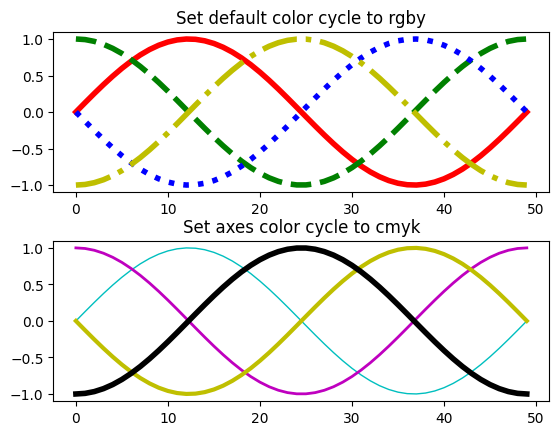

In [5]:
custom_cycler = (cycler(color=['c', 'm', 'y', 'k']) +
                 cycler(lw=[1, 2, 3, 4]))

fig, (ax0, ax1) = plt.subplots(nrows=2)
ax0.plot(yy)
ax0.set_title('Set default color cycle to rgby')
ax1.set_prop_cycle(custom_cycler)
ax1.plot(yy)
ax1.set_title('Set axes color cycle to cmyk')

# Add a bit more space between the two plots.
fig.subplots_adjust(hspace=0.3)
plt.show()

### Setting prop_cycle in the matplotlibrc file or style files
- Remember, a custom cycler can be set in your matplotlibrc file or a style file (style.mplstyle) under axes.prop_cycle:

In [ ]:
axes.prop_cycle : cycler(color='bgrcmyk')

### Cycling through multiple properties

In [7]:
from cycler import cycler
cc = (cycler(color=list('rgb')) +
      cycler(linestyle=['-', '--', '-.']))
for d in cc:
    print(d)

{'color': 'r', 'linestyle': '-'}
{'color': 'g', 'linestyle': '--'}
{'color': 'b', 'linestyle': '-.'}


In [8]:
from cycler import cycler
cc = (cycler(color=list('rgb')) *
      cycler(linestyle=['-', '--', '-.']))
for d in cc:
    print(d)

{'color': 'r', 'linestyle': '-'}
{'color': 'r', 'linestyle': '--'}
{'color': 'r', 'linestyle': '-.'}
{'color': 'g', 'linestyle': '-'}
{'color': 'g', 'linestyle': '--'}
{'color': 'g', 'linestyle': '-.'}
{'color': 'b', 'linestyle': '-'}
{'color': 'b', 'linestyle': '--'}
{'color': 'b', 'linestyle': '-.'}
